c:\Users\miran\AppData\Local\Programs\Python\Python311\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data.myhome.go.kr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


총 993건의 데이터를 수집했습니다.
데이터 🟠정제 완료: 모든 {}를 빈칸으로 변경했습니다.
                    hsmpNm 주택 유형명  suplyPrvuseAr  bassRentGtn      공급물량
503                    희준빌  다세대주택          31.45     41420000  31473523
504                    희준빌  다세대주택          31.45     42210000  31473523
563                    백년빌  다세대주택          32.34     38480000  31406689
564                    백년빌  다세대주택          35.34     43000000  31406689
591                  더그린역삼  다세대주택          32.89     40940000  31397678
593                  더그린역삼  다세대주택          34.62     42610000  31397678
592                  더그린역삼  다세대주택          35.50     43290000  31397678
595                  더그린역삼  다세대주택          32.89     40940000  31397678
600                  더그린역삼  다세대주택          34.57     44770000  31397678
597                  더그린역삼  다세대주택          34.62     42610000  31397678
596                  더그린역삼  다세대주택          35.50     43290000  31397678
601                  더그린역삼  다세대주택          31.72     42310000  31397678
610        

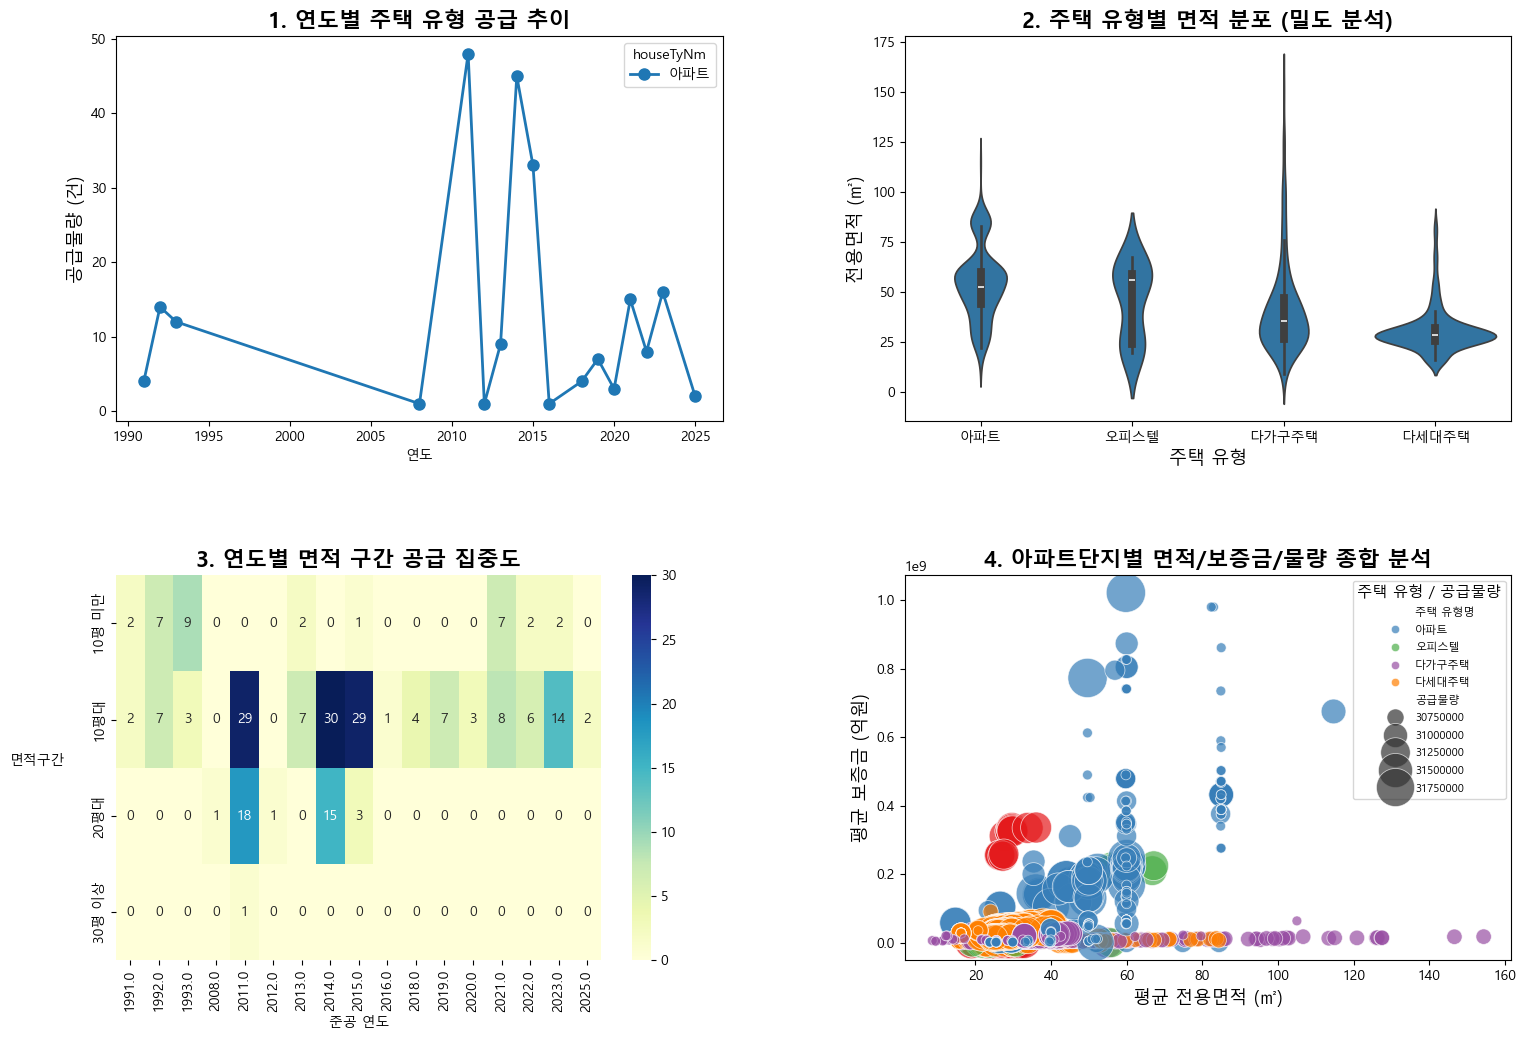

In [ ]:
# 이전 파일 강남구 다른 그래프로
# 준공('pblancDe') 날짜데이터-연도만
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 수집
base_url = "https://data.myhome.go.kr:443/rentalHouseList" 
service_key = "6114f483bd6368bb21a7995881e36487d6baeae732d0dcdd3c719842dd0d35ed"

params = {
    'ServiceKey': service_key,
    'brtcCode': '11', 
    'signguCode': '680', #강남구 엑셀 기본제공 자료파일
    'numOfRows': '2000', 
    # 'pageNo': '1',    
}

response = requests.get(base_url, params=params, verify=False)
data = response.json()

if 'hsmpList' in data:
    df = pd.DataFrame(data['hsmpList'])
    print(f"총 {len(df)}건의 데이터를 수집했습니다.")
    # print(df.head()) #🟠
    # df.to_excel('LH_save680.xlsx', index=False)
    # print("--- LH_save680.xlsx 파일 저장 완료! ---") 

    # [필수 전처리 1] 🧹 삭제 대신 {}만 빈칸("")으로 바꾸기
    df = df.map(lambda x: "기타" if x == {} else x)
    print("데이터 🟠정제 완료: 모든 {}를 '기타'로 변경했습니다.")

    # [필수 전처리 2] 🧹 숫자형으로 수치 데이터 타입 변환
    # 준공('pblancDe')가 문자열이므로 날짜형으로 바꾸고 '연도'만 뽑습니다.
    df['competDe'] = pd.to_datetime(df['competDe'], errors='coerce')
    df['연도'] = df['competDe'].dt.year

    # 2. 시각화 설정
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3) #그래프 사이간격 h위아래, 좌우

    # (1) Line Chart 연도별+주택유형별 공급 추이
    # 연도와 주택유형 그룹화, size개수 세고, unstack 세로로 길게 늘어진 데이터를 가로 표로 펼침
    yearly_type_trend = df.groupby(['연도', 'houseTyNm']).size().unstack().fillna(0)
    yearly_type_trend.plot(kind='line', marker='o', linewidth=2, markersize=8, ax=axes[0,0])

    axes[0,0].set_title('1. 연도별 주택 유형 공급 추이', fontsize=16, fontweight='bold')
    axes[0,0].set_ylabel('공급물량 (건)', fontsize=13) #rotation=0, labelpad=40 💡 rotation=0으로 가로 정렬
    # axes[0,0].set_xlabel('공고 연도', fontsize=13) #🍋2️⃣
    # axes[0,0].grid(True, linestyle='--', alpha=0.5) #🍋2️⃣
    # 범례 위치 조정 🍋2️⃣
    # axes[0,0].legend(title='주택 유형', title_fontsize='11', loc='upper left')

    # (2) Violin Plot - (BoxPlot 업그레이드) 주택유형별 면적 분포
    # sns.violinplot(data=df, x='houseTyNm', y='suplyPrvuseAr', palette='Pastel1', inner="quartile", ax=axes[0,1])
    sns.violinplot(data=df[df['houseTyNm'] != ""], x='houseTyNm', y='suplyPrvuseAr', ax=axes[0,1]) #3️⃣빈 값("")을 가진 행을 제외
    axes[0,1].set_title('2. 주택 유형별 면적 분포 (밀도 분석)', fontsize=16, fontweight='bold')
    axes[0,1].set_ylabel('전용면적 (㎡)', fontsize=13)
    axes[0,1].set_xlabel('주택 유형', fontsize=13)

    # (3) 히트맵 Heatmap: 🟢 면적 구간별 공급 집중도
    # 💡 [추가 전처리] 면적 구간 나누기 (Binning)
    df['pyeong'] = df['suplyPrvuseAr'] * 0.3025 # 평수 계산
    bins = [0, 10, 20, 30, 100]
    labels = ['10평 미만', '10평대', '20평대', '30평 이상']
    df['면적구간'] = pd.cut(df['pyeong'], bins=bins, labels=labels, right=False)

    heatmap_data = df.pivot_table(index='면적구간', columns='연도', values='hsmpSn', aggfunc='count').fillna(0)
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', ax=axes[1,0])
    axes[1,0].set_title('3. 연도별 면적 구간 공급 집중도', fontsize=16, fontweight='bold')
    axes[1,0].set_ylabel('면적구간', rotation=0, labelpad=40)
    axes[1,0].set_xlabel('준공 연도')

    # (4) 산점도 Scatter plot: 면적 x 보증금 x 유형(색) x 물량(점 크기)
    # 데이터 집계: 산점도에 그릴 데이터를 미리 정리 (평균 보증금, 평균 면적, 공급물량)
    # 💡 범례 제목을 '주택 유형명'으로 바꾸기 위해 hue 파라미터에 전달할 컬럼명을 미리 바꿉니다.
    scatter_df = df.rename(columns={'houseTyNm': '주택 유형명', 'hsmpSn': '공급물량'})

    # 💡 'size' 옵션에 물량(hsmpSn)을 넣고, 'sizes'로 크기 범위를 지정
    sns.scatterplot(data=scatter_df, x='suplyPrvuseAr', y='bassRentGtn', #🟠1️⃣hue이름바꿔야 size도
                    hue='주택 유형명', size='공급물량', sizes=(50, 800), # 점 크기 범위 키움
                    alpha=0.7, palette='Set1', ax=axes[1,1])

    axes[1,1].set_title('4. 아파트단지별 면적/보증금/물량 종합 분석', fontsize=16, fontweight='bold')
    axes[1,1].set_ylabel('평균 보증금 (억원)', fontsize=13)
    axes[1,1].set_xlabel('평균 전용면적 (㎡)', fontsize=13)
    # 범례가 너무 크면 조정 (bbox_to_anchor로 위치 세밀 조정 가능)
    axes[1,1].legend(title='주택 유형 / 공급물량', title_fontsize='11', loc='upper right', fontsize='8')

    # 👼
    # 면적: 30~45 사이 / 보증금: 2,000만~4,000만 사이 / 물량: 100건 이상인 것만
    target_data = scatter_df[
        (scatter_df['suplyPrvuseAr'] >= 30) & (scatter_df['suplyPrvuseAr'] <= 45) &
        (scatter_df['bassRentGtn'] >= 20000000) & (scatter_df['bassRentGtn'] <= 45000000) &
        (scatter_df['공급물량'] >= 100)
    ]
    print(target_data[['hsmpNm', '주택 유형명', 'suplyPrvuseAr', 'bassRentGtn', '공급물량']].sort_values(by='공급물량', ascending=False))
    
    plt.show()
else:
    print("데이터를 불러오지 못했습니다. API 응답을 확인하세요.")